# PART 1

In [1]:
!pip install torch torchvision matplotlib numpy scikit-learn --quiet

In [2]:
#SETUP
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt
import numpy as np
device = 'cuda'
BATCH_SIZE, LATENT_DIM = 128,8


In [3]:
#Data Loading
transform = transforms.ToTensor()

train_ds = datasets.FashionMNIST(root='data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 214kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.76MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.6MB/s]


In [6]:
#VAE architecture
class VAE(nn.Module):
    def __init__(self, latent_dim=8):
      super().__init__()
      #Layers to encode spatial structure of the clothing images from 28x28->14x14->7x7
      self.encoder = nn.Sequential(
          nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
          nn.ReLU(),
          nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
          nn.ReLU()
      )
      #Map encoded image to the latent distribution
      self.fc_mu = nn.Linear(7*7*64, latent_dim)
      self.fc_logvar = nn.Linear(7*7*64, latent_dim)

      #Map latent distribution vector back to image features
      self.fc_decode = nn.Linear(latent_dim, 7*7*64)

      #Now going back from latent space from 7x7->14x14->28x28
      self.decoder = nn.Sequential(nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
                                   nn.ReLU(),
                                   nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
                                   nn.Sigmoid())
    def encode(self, x):
        h = self.encoder(x).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(-1, 64, 7, 7)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

#VAE Loss
def vae_loss(recon_x, x, mu, logvar):
  recon_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
  kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
  return recon_loss + kl_div

In [18]:
# VAE training on FashionMNIST for 30 epochs
vae = VAE(latent_dim=LATENT_DIM).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)
EPOCHS = 30

for epoch in range(EPOCHS):
  vae.train()
  train_loss = 0
  for x,_ in train_loader:
    x = x.to(device)
    optimizer.zero_grad()
    recon_x, mu, logvar = vae(x)
    loss = vae_loss(recon_x, x, mu, logvar)
    loss.backward()
    train_loss += loss.item()
    optimizer.step()
  print(f'Epoch: {epoch+1}, Loss: {train_loss/len(train_loader.dataset)}')

Epoch: 1, Loss: 275.1170217122396
Epoch: 2, Loss: 251.08671676432292
Epoch: 3, Loss: 247.8253599283854
Epoch: 4, Loss: 246.0263939778646
Epoch: 5, Loss: 244.94937389322916
Epoch: 6, Loss: 244.16240423177084
Epoch: 7, Loss: 243.57949729817707
Epoch: 8, Loss: 243.1308326171875
Epoch: 9, Loss: 242.71081451822917
Epoch: 10, Loss: 242.40391067708333
Epoch: 11, Loss: 242.10460504557292
Epoch: 12, Loss: 241.86585244140625
Epoch: 13, Loss: 241.650782421875
Epoch: 14, Loss: 241.47688232421876
Epoch: 15, Loss: 241.25134140625
Epoch: 16, Loss: 241.1189055013021
Epoch: 17, Loss: 240.96832262369793
Epoch: 18, Loss: 240.82886842447917
Epoch: 19, Loss: 240.70719755859375
Epoch: 20, Loss: 240.5890844075521
Epoch: 21, Loss: 240.5099582356771
Epoch: 22, Loss: 240.42622122395832
Epoch: 23, Loss: 240.316249609375
Epoch: 24, Loss: 240.21665501302084
Epoch: 25, Loss: 240.1530716796875
Epoch: 26, Loss: 240.07979007161458
Epoch: 27, Loss: 240.00503697916668
Epoch: 28, Loss: 239.91651910807292
Epoch: 29, Loss:

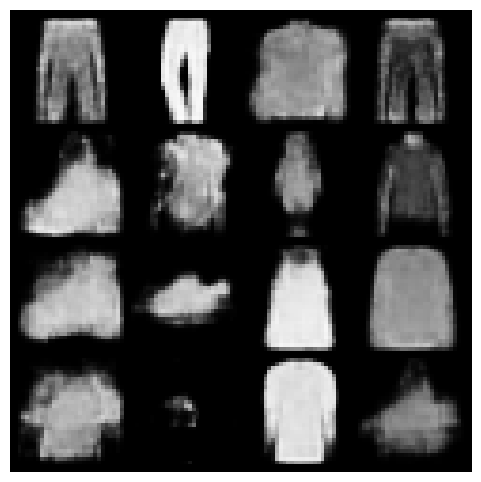

In [19]:
#Visualisation grid
@torch.no_grad()
def generate_vae(model,n=16):
  model.eval()
  z = torch.randn(n, LATENT_DIM, device=device)
  return model.decode(z).cpu()

samples = generate_vae(vae)
grid = utils.make_grid(samples, nrow=4, padding=2)

plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.axis("off")
plt.show()

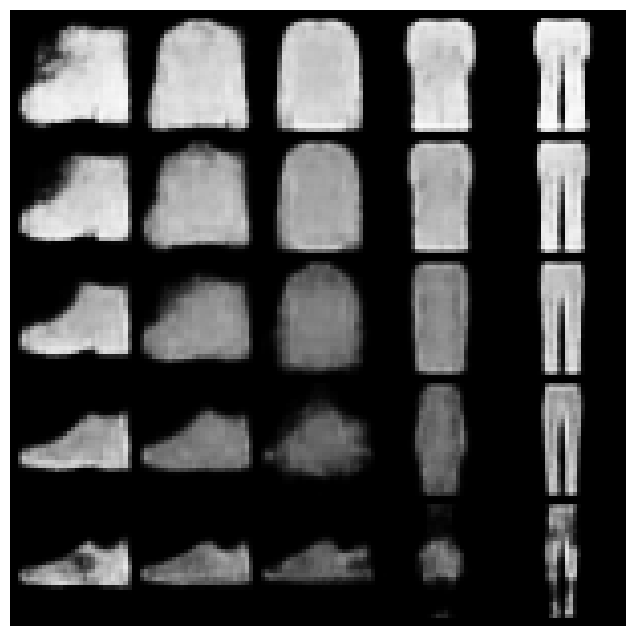

In [20]:
#Latent space experiment
@torch.no_grad()
def latent_grid(model):
  model.eval()

  values = torch.linspace(-2, 2, 5)
  zs = []

  for z0 in values:
    for z1 in values:
      z = torch.zeros(LATENT_DIM)
      z[0] = z0
      z[1] = z1
      zs.append(z)

  z = torch.stack(zs).to(device)
  return model.decode(z).cpu()

samples = latent_grid(vae)
grid = utils.make_grid(samples, nrow=5)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.axis("off")
plt.show()


## How does your VAE compare to the MNIST VAE? Are the outputs sharper, blurrier, more or less recognisable? What properties of your dataset make it harder or easier to generate from?


Compared to the MNIST VAE, the outputs are blurrier here with FMNIST. This does make sense though as the level of detail needed for a sharper image is higher. They are also harder to recognize as the dataset requires higher detail for the fashion items. The dataset here is not just digits but more complicated figure and details.

I see this in the grid itself as well, where some items of clothing look ambiguous to where I can't tell if it's a dress, shirt, or another article of clothing. Since our VAE is compressing a lot of the pixel information into a small latent vector, those fine details become the dealbreakers that can be lost during compression+reconstruction. Thus, longer epochs, learning rate schedulers, and other forms of training our VAE could potentially come in more handy here than for the MNIST dataset, but the VAE is clearly leveraging its architecture to generate images quickly and leanly.

From the latent-space interpretation, the main thing I notice is that neither z0 nor z1 work with one property. I feel it is difficult to find whether one exact feature influences some property of generation, so I'm thinking that this could suggest the VAE learned a continuous latent space where the features are somewhat entangled rather than each latent dimension controlling one clearly separable property

# PART 2

In [17]:
#Loading GAN-specific dataset here and normalizing to [-1,1] for preprocessing
gan_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

gan_ds = datasets.FashionMNIST(
    "./data",
    train=True,
    download=True,
    transform=gan_transform
)

gan_loader = DataLoader(
    gan_ds,
    batch_size=128,
    shuffle=True,
    drop_last=True
)

Z_DIM = 64

In [22]:
#Use the same generator and discriminator for GANs A/B/C
class Generator(nn.Module):
    def __init__(self, z_dim=64):
        super().__init__()

        self.fc = nn.Linear(z_dim, 128 * 7 * 7)

        self.net = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 1, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 128, 7, 7)
        return self.net(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1)
        )

    def forward(self, x):
        return self.net(x)

In [27]:
#Training loop for GAN A+B
def train_bce_gan(lr_g, lr_d, epochs=30):
    G = Generator(Z_DIM).to(device)
    D = Discriminator().to(device)

    opt_g = torch.optim.Adam(
        G.parameters(), lr=lr_g, betas=(0.5, 0.999)
    )

    opt_d = torch.optim.Adam(
        D.parameters(), lr=lr_d, betas=(0.5, 0.999)
    )

    criterion = nn.BCEWithLogitsLoss()

    g_history = []
    d_history = []

    for epoch in range(epochs):
        epoch_g = []
        epoch_d = []

        for real, _ in gan_loader:
            real = real.to(device)
            n = real.size(0)

            # ----- Train D -----
            z = torch.randn(n, Z_DIM, device=device)
            fake = G(z)

            real_loss = criterion(
                D(real),
                torch.ones(n, 1, device=device)
            )

            fake_loss = criterion(
                D(fake.detach()),
                torch.zeros(n, 1, device=device)
            )

            d_loss = real_loss + fake_loss

            opt_d.zero_grad()
            d_loss.backward()
            opt_d.step()

            # ----- Train G -----
            g_loss = criterion(
                D(fake),
                torch.ones(n, 1, device=device)
            )

            opt_g.zero_grad()
            g_loss.backward()
            opt_g.step()

            epoch_g.append(g_loss.item())
            epoch_d.append(d_loss.item())

        g_history.append(sum(epoch_g) / len(epoch_g))
        d_history.append(sum(epoch_d) / len(epoch_d))

        print(
            epoch + 1,
            f"G loss: {round(g_history[-1], 3)}",
            f"D loss: {round(d_history[-1], 3)}"
        )

    return G, D, g_history, d_history

In [23]:
# WGAN-GP architecture
def gradient_penalty(D, real, fake):
    n = real.size(0)

    alpha = torch.rand(n, 1, 1, 1, device=device)

    mixed = alpha * real + (1 - alpha) * fake
    mixed.requires_grad_(True)

    score = D(mixed)

    grad = torch.autograd.grad(
        outputs=score,
        inputs=mixed,
        grad_outputs=torch.ones_like(score),
        create_graph=True,
        retain_graph=True
        )[0]

    grad = grad.view(n, -1)

    return ((grad.norm(2, dim=1) - 1) ** 2).mean()

def train_wgan_gp(epochs=30, gp_weight=10, n_critic=5):
    G = Generator(Z_DIM).to(device)
    D = Discriminator().to(device)

    opt_g = torch.optim.Adam(
        G.parameters(), lr=1e-4, betas=(0.0, 0.9)
    )

    opt_d = torch.optim.Adam(
        D.parameters(), lr=1e-4, betas=(0.0, 0.9)
    )

    g_history = []
    d_history = []

    for epoch in range(epochs):
        epoch_g = []
        epoch_d = []

        for real, _ in gan_loader:
            real = real.to(device)
            n = real.size(0)

            # Train critic several times.
            for _ in range(n_critic):
                z = torch.randn(n, Z_DIM, device=device)
                fake = G(z).detach()

                gp = gradient_penalty(D, real, fake)

                d_loss = (
                    D(fake).mean()
                    - D(real).mean()
                    + gp_weight * gp
                )

                opt_d.zero_grad()
                d_loss.backward()
                opt_d.step()

            # Train generator.
            z = torch.randn(n, Z_DIM, device=device)
            fake = G(z)

            g_loss = -D(fake).mean()

            opt_g.zero_grad()
            g_loss.backward()
            opt_g.step()

            epoch_g.append(g_loss.item())
            epoch_d.append(d_loss.item())

        g_history.append(sum(epoch_g) / len(epoch_g))
        d_history.append(sum(epoch_d) / len(epoch_d))

        print(
            epoch + 1,
            f"G loss: {round(g_history[-1], 3)}",
            f"D loss: {round(d_history[-1], 3)}"
        )

    return G, D, g_history, d_history

In [29]:
#Version A
print("Training GAN A\n")
G_A, D_A, gA, dA = train_bce_gan(lr_g = 2e-4, lr_d=2e-4, epochs=30)
print("\nTraining GAN B\n")
#Version B: higher learning rate (instability)
G_B, D_B, gB, dB = train_bce_gan(lr_g = 2e-4, lr_d=2e-3, epochs=30)
# Version C: WGAN-GP
print("\nTraining GAN C\n")
G_C, D_C, gC, dC = train_wgan_gp(epochs=30)

Training GAN A

1 G loss: 1.134 D loss: 1.002
2 G loss: 0.943 D loss: 1.121
3 G loss: 0.981 D loss: 1.095
4 G loss: 0.965 D loss: 1.128
5 G loss: 0.946 D loss: 1.154
6 G loss: 1.055 D loss: 1.16
7 G loss: 0.931 D loss: 1.17
8 G loss: 0.934 D loss: 1.172
9 G loss: 0.938 D loss: 1.17
10 G loss: 0.945 D loss: 1.163
11 G loss: 0.953 D loss: 1.158
12 G loss: 0.964 D loss: 1.153
13 G loss: 0.971 D loss: 1.147
14 G loss: 0.975 D loss: 1.141
15 G loss: 0.985 D loss: 1.14
16 G loss: 0.987 D loss: 1.142
17 G loss: 0.989 D loss: 1.137
18 G loss: 0.995 D loss: 1.135
19 G loss: 0.999 D loss: 1.133
20 G loss: 1.004 D loss: 1.131
21 G loss: 1.008 D loss: 1.129
22 G loss: 1.012 D loss: 1.129
23 G loss: 1.015 D loss: 1.128
24 G loss: 1.018 D loss: 1.123
25 G loss: 1.031 D loss: 1.122
26 G loss: 1.029 D loss: 1.117
27 G loss: 1.034 D loss: 1.118
28 G loss: 1.038 D loss: 1.114
29 G loss: 1.041 D loss: 1.115
30 G loss: 1.046 D loss: 1.11

Training GAN B

1 G loss: 3.246 D loss: 0.47
2 G loss: 3.177 D loss

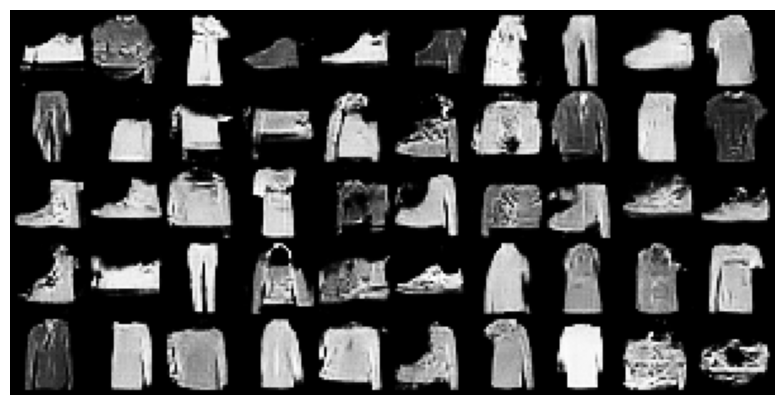

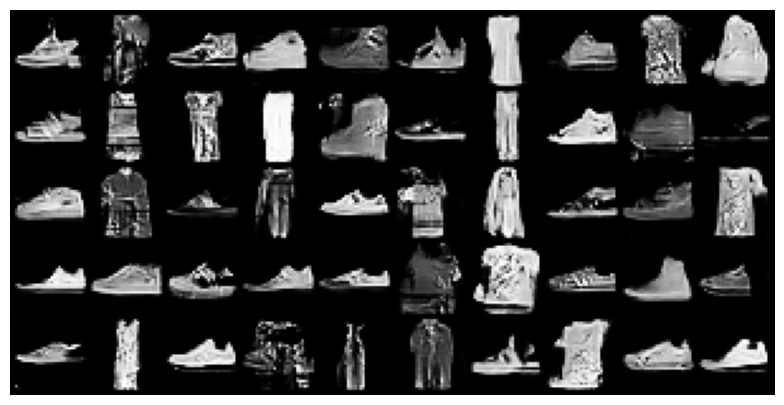

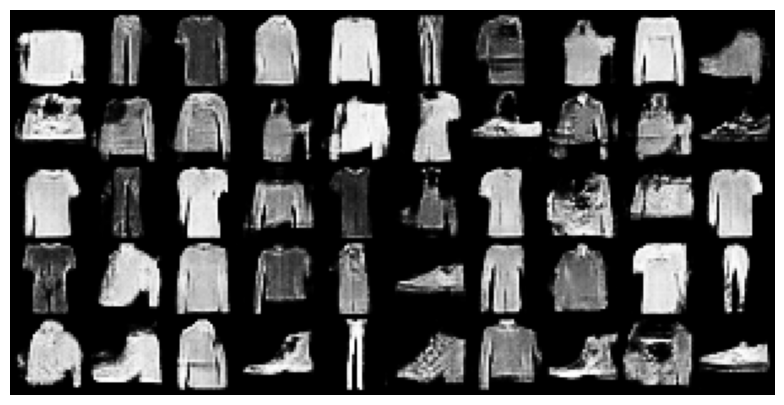

In [31]:
@torch.no_grad()
def show_gan_samples(G, n=50, nrow=10):
    G.eval()

    z = torch.randn(n, Z_DIM, device=device)
    imgs = G(z).cpu()

    # [-1, 1] -> [0, 1]
    imgs = (imgs + 1) / 2

    grid = utils.make_grid(imgs, nrow=nrow)

    plt.figure(figsize=(10, 5))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.axis("off")
    plt.show()

show_gan_samples(G_A)
show_gan_samples(G_B)
show_gan_samples(G_C)

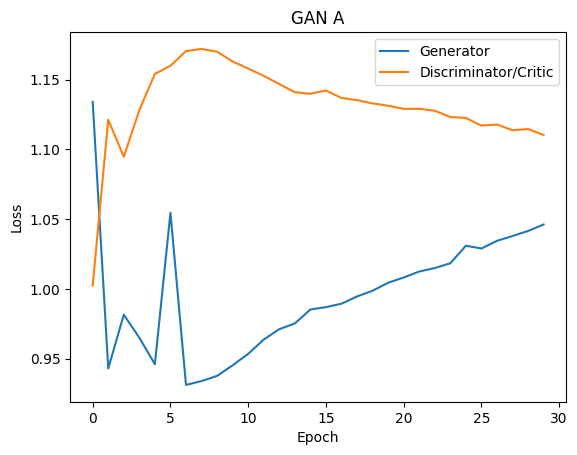

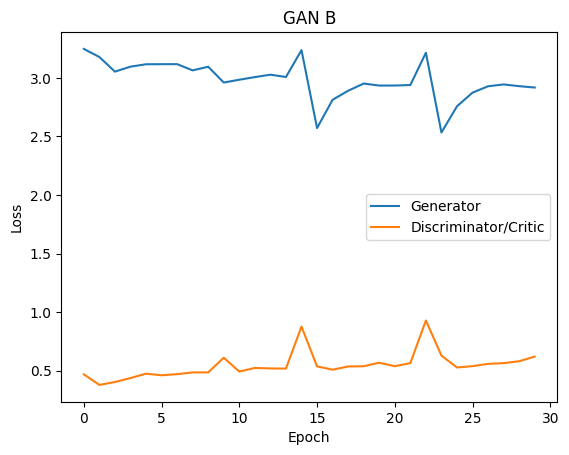

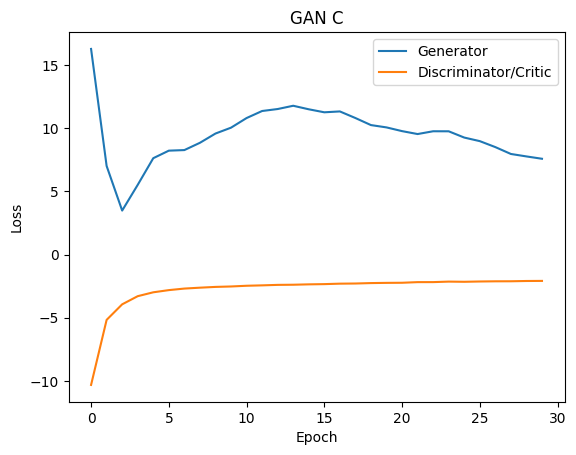

In [32]:
def plot_losses(g_loss, d_loss, title):
    plt.plot(g_loss, label="Generator")
    plt.plot(d_loss, label="Discriminator/Critic")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.show()

plot_losses(gA, dA, "GAN A")
plot_losses(gB, dB, "GAN B")
plot_losses(gC, dC, "GAN C")

In [33]:
!pip -q install torchmetrics torch-fidelity --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 11.1 MB/s eta 0:00:00


In [37]:
from torchmetrics.image.fid import FrechetInceptionDistance

@torch.no_grad()
def calculate_fid(G, loader, n_images=500):
    fid = FrechetInceptionDistance(
        feature=2048,
        normalize=True
    ).to(device)

    count = 0

    for real, _ in loader:
        remaining = n_images - count

        if remaining <= 0:
            break

        real = real[:remaining].to(device)

        # [-1,1] -> [0,1]
        real = (real + 1) / 2

        # Inception expects RGB.
        real = real.repeat(1, 3, 1, 1)

        fid.update(real, real=True)
        count += len(real)

    count = 0

    while count < n_images:
        n = min(100, n_images - count)

        z = torch.randn(n, Z_DIM, device=device)
        fake = G(z)

        fake = (fake + 1) / 2
        fake = fake.repeat(1, 3, 1, 1)

        fid.update(fake, real=False)
        count += n

    return fid.compute().item()
fid_A = calculate_fid(G_A, gan_loader)
fid_B = calculate_fid(G_B, gan_loader)
fid_C = calculate_fid(G_C, gan_loader)

print("GAN A:", round(fid_A,2), " GAN B:", round(fid_B,2), " GAN C:", round(fid_C,2))

GAN A: 71.68  GAN B: 104.14  GAN C: 75.6


In [38]:
import pandas as pd

comparison_table = pd.DataFrame({
    "Version": [
        "A — Standard GAN",
        "B — Unbalanced GAN",
        "C — WGAN-GP"
    ],

    "FID": [
        round(fid_A, 2),
        round(fid_B, 2),
        round(fid_C, 2)
    ],

    # Fill these from YOUR observations.
    "Diversity": [
        "STRONG diversity: shoes, boots, pants, shirts, etc.",
        "WEAK diversity: Repetitive distributions, lots of footwear",
        "STRONG diversity: clear and recognizable class samples"
    ],

    "Loss behaviour": [
        "STABLE: G and D remain stable after early epochs",
        "UNSTABLE: D sits much lower while G reaches around three, with lots of noise",
        "STABLE: generator and critic remain stable and plateau after early epochs"
    ],

    "Your verdict": [
        "Strong and stable overall, good diversity",
        "Less stable+diverse, with strong discriminator dominance + some mode collapse",
        "Stable training and diversity, gradient penalty seems to have helped in comparison to B"
    ]
})

comparison_table

,Version,FID,Diversity,Loss behaviour,Your verdict
0,A — Standard GAN,71.68,"STRONG diversity: shoes, boots, pants, shirts,...",STABLE: G and D remain stable after early epochs,"Strong and stable overall, good diversity"
1,B — Unbalanced GAN,104.14,"WEAK diversity: Repetitive distributions, lots...",UNSTABLE: D sits much lower while G reaches ar...,"Less stable+diverse, with strong discrimnator ..."
2,C — WGAN-GP,75.60,STRONG diversity: clear an drecognizable class...,STABLE: G and D remain stable and plateau afte...,"Stable training and diversity, gradient penalt..."


## Does WGAN-GP actually fix mode collapse in your experiment? If not, what else could explain any remaining instability?


Yes, WGAN-GP did help recover the majority of the instability created by the discriminator dominance in B's training. This is seen in the drop of FID back to the standard GAN's FID ranges, however GAN A was the strongest overall baseline.

This is also seen in the results: A provides a good mix of relatively separable categories and images as well as strong diversity, so the lower FID score echoes these observations by showing that the learned distribution is statistically closer to that of the real image distributions than B or C.

B fared the worst due to making the discriminator 10x faster. The image grid produced by B echoes this with a large dip in diversity (footwear-heavy grid) and noisy loss curves, all pointing to partial mode collapse where a strong discriminator leads the generator to cling to a small output family.

All in all, WGAN-GP improved diversity and stability issues seen in B, but its worse FID compared to A's do not suggest to me that WGAN-GP was strictly better than a well-balanced standard GAN.